In [2]:
# ============================================================
# Step 7 setup: read Step 6 JSON
#
# This script visualizes the existing Step 6 output JSON.
# It does not require rerunning Step 6.
# ============================================================

import os
import json
import math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

# ------------------------------------------------------------
# 1. Set Step 6 JSON path
# ------------------------------------------------------------

json_path = Path(
    "/content/drive/MyDrive/Colab Notebooks/linear_probe_pilot4/expA_settingA_6fps/settingA/data_expA_6fps_settingA/p4_settingA_step6.json"
)

# If you uploaded the file directly to /content, use this instead:
# json_path = Path("/content/step6_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features.json")

output_dir = Path("/content/step7_pilot4_single_direction_train_figures")
output_dir.mkdir(parents=True, exist_ok=True)

print("Step 6 JSON exists:", json_path.exists())
print("Step 6 JSON path:", json_path)
print("Output dir:", output_dir)

if not json_path.exists():
    raise FileNotFoundError(f"Step 6 JSON not found: {json_path}")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print("\nLoaded Step 6 JSON.")
print("Top-level keys:")
print(list(data.keys()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Step 6 JSON exists: True
Step 6 JSON path: /content/drive/MyDrive/Colab Notebooks/linear_probe_pilot4/expA_settingA_6fps/settingA/data_expA_6fps_settingA/p4_settingA_step6.json
Output dir: /content/step7_pilot4_single_direction_train_figures

Loaded Step 6 JSON.
Top-level keys:
['experiment_name', 'description', 'model_name', 'model_tag', 'feature_key', 'label_field', 'num_samples_loaded', 'num_layers', 'feature_dim', 'label_order', 'scene_split_info', 'test_subset_summary', 'step6_config', 'source_pt_files', 'results_by_layer']


In [3]:
# ============================================================
# Basic metadata and structure checks
# ============================================================

experiment_name = data.get("experiment_name", "unknown_experiment")
model_tag = data.get("model_tag", "unknown_model")
feature_key = data.get("feature_key", "unknown_feature")
label_order = data.get("label_order")

results_by_layer = data.get("results_by_layer", [])

if not results_by_layer:
    raise ValueError("No results_by_layer found in Step 6 JSON.")

if label_order is None:
    label_order = results_by_layer[0]["test_overall"]["label_order"]

num_layers = data.get("num_layers", len(results_by_layer))
scene_split_info = data.get("scene_split_info", {})
test_subset_summary = data.get("test_subset_summary", {})
step6_config = data.get("step6_config", {})

subset_keys = ["test_overall", "test_direct", "test_inverse"]

print("Experiment:", experiment_name)
print("Model:", model_tag)
print("Feature:", feature_key)
print("Num layers:", num_layers)
print("Labels:", label_order)

print("\nStep 6 description:")
print(data.get("description", ""))

print("\nTrain direction filter info:")
print(json.dumps(scene_split_info.get("train_direction_filter_info", {}), indent=2, ensure_ascii=False))

print("\nTest subset summary:")
print(json.dumps(test_subset_summary, indent=2, ensure_ascii=False))

# Required keys check
for layer_result in results_by_layer:
    for subset_key in subset_keys:
        if subset_key not in layer_result:
            raise KeyError(f"Missing subset {subset_key} in layer {layer_result.get('layer')}")
        for key in ["accuracy", "macro_f1", "classification_report", "confusion_matrix", "label_order"]:
            if key not in layer_result[subset_key]:
                raise KeyError(f"Missing key {key} in {subset_key}, layer {layer_result.get('layer')}")

print("\nStructure check passed.")

Experiment: scene_split_single_direction_train_preserve_text_direction
Model: Qwen2_5_3B
Feature: layer_diff_features
Num layers: 37
Labels: ['above', 'below', 'contains', 'in', 'left_of', 'near', 'on', 'right_of', 'supports']

Step 6 description:
Scene-split single-direction-train evaluation. Training uses one randomly selected direction per direct/inverse pair group from train scenes. Testing keeps all direct and inverse samples from test scenes, with separate evaluation for overall, direct subset, and inverse subset.

Train direction filter info:
{
  "enabled": true,
  "mode": "random",
  "apply_to_train_only": true,
  "group_key": "pair_group_id",
  "num_train_before_direction_filter": 2434,
  "num_train_after_direction_filter": 1232,
  "summary": {
    "num_groups": 1232,
    "num_groups_with_both_directions": 1202,
    "num_groups_direct_only": 30,
    "num_groups_inverse_only": 0,
    "num_groups_other": 0,
    "kept_direct": 615,
    "kept_inverse": 617,
    "kept_other": 0,
  

In [4]:
# ============================================================
# Build layer-wise dataframe
# ============================================================

def build_layerwise_dataframe(data):
    rows = []

    for layer_result in data["results_by_layer"]:
        layer = int(layer_result["layer"])

        row = {
            "layer": layer,
            "train_accuracy": layer_result["train"]["accuracy"],
            "train_macro_f1": layer_result["train"]["macro_f1"],
        }

        for subset_key in ["test_overall", "test_direct", "test_inverse"]:
            row[f"{subset_key}_accuracy"] = layer_result[subset_key]["accuracy"]
            row[f"{subset_key}_macro_f1"] = layer_result[subset_key]["macro_f1"]
            row[f"{subset_key}_num_examples"] = layer_result[subset_key]["num_examples"]

        rows.append(row)

    return pd.DataFrame(rows)


layerwise_df = build_layerwise_dataframe(data)

csv_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_layerwise_metrics.csv"
layerwise_df.to_csv(csv_path, index=False)

print("Saved layerwise metrics:")
print(csv_path)

display(layerwise_df.head())

Saved layerwise metrics:
/content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_layerwise_metrics.csv


,layer,train_accuracy,train_macro_f1,test_overall_accuracy,test_overall_macro_f1,test_overall_num_examples,test_direct_accuracy,test_direct_macro_f1,test_direct_num_examples,test_inverse_accuracy,test_inverse_macro_f1,test_inverse_num_examples
0,0,0.646916,0.428400,0.435460,0.288677,1348,0.438053,0.298509,678,0.432836,0.281454,670
1,1,0.969968,0.964891,0.715875,0.597550,1348,0.735988,0.653871,678,0.695522,0.518846,670
2,2,0.991883,0.991911,0.795994,0.663788,1348,0.820059,0.717024,678,0.771642,0.582321,670
3,3,0.996753,0.996826,0.801187,0.671857,1348,0.823009,0.729171,678,0.779104,0.587657,670
4,4,0.998377,0.998430,0.760386,0.620849,1348,0.774336,0.692700,678,0.746269,0.533820,670


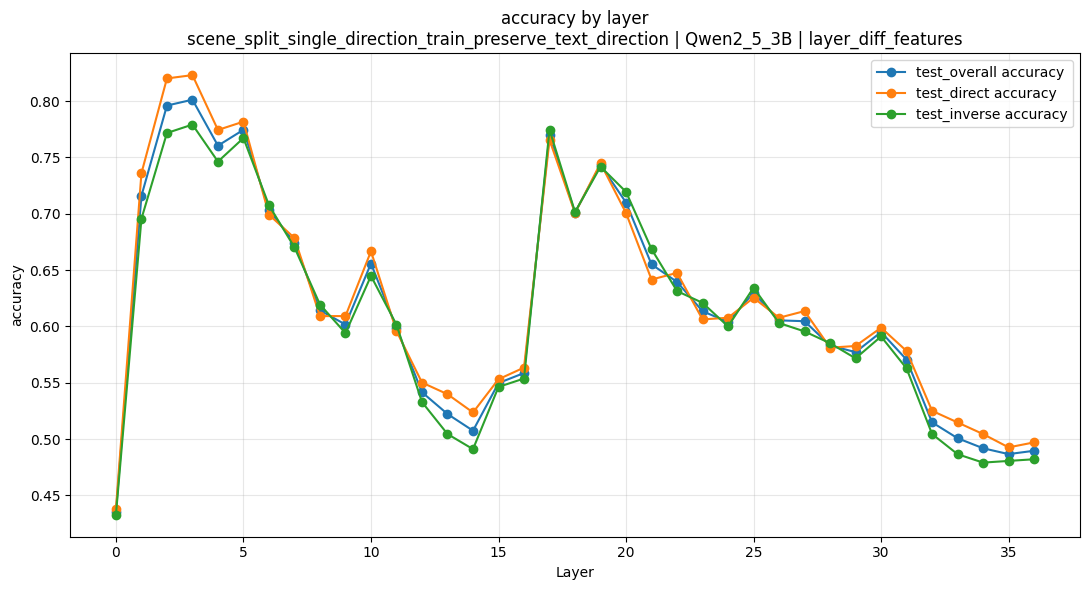

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_layerwise_accuracy.png


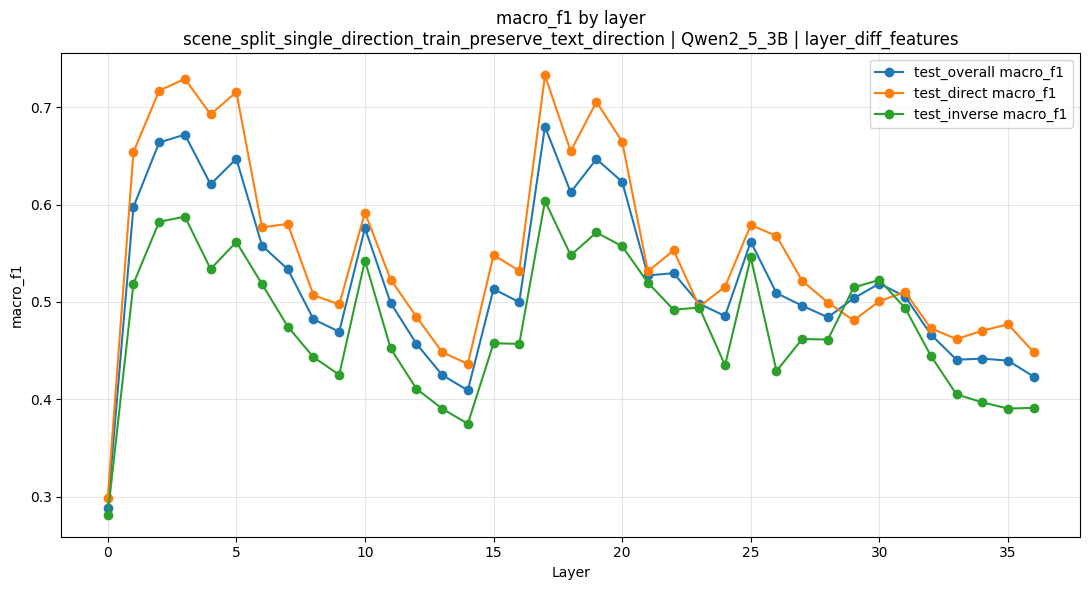

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_layerwise_macro_f1.png


In [5]:
# ============================================================
# Plot layer-wise accuracy / macro-F1 curves
# ============================================================

def plot_layerwise_metric_curves(df, metric_name, output_dir):
    """
    metric_name:
      "accuracy" or "macro_f1"
    """

    plt.figure(figsize=(11, 6))

    plt.plot(
        df["layer"],
        df[f"test_overall_{metric_name}"],
        marker="o",
        label=f"test_overall {metric_name}",
    )

    plt.plot(
        df["layer"],
        df[f"test_direct_{metric_name}"],
        marker="o",
        label=f"test_direct {metric_name}",
    )

    plt.plot(
        df["layer"],
        df[f"test_inverse_{metric_name}"],
        marker="o",
        label=f"test_inverse {metric_name}",
    )

    plt.xlabel("Layer")
    plt.ylabel(metric_name)
    plt.title(
        f"{metric_name} by layer\n"
        f"{experiment_name} | {model_tag} | {feature_key}"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_layerwise_{metric_name}.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()

    print("Saved:", fig_path)


plot_layerwise_metric_curves(layerwise_df, "accuracy", output_dir)
plot_layerwise_metric_curves(layerwise_df, "macro_f1", output_dir)

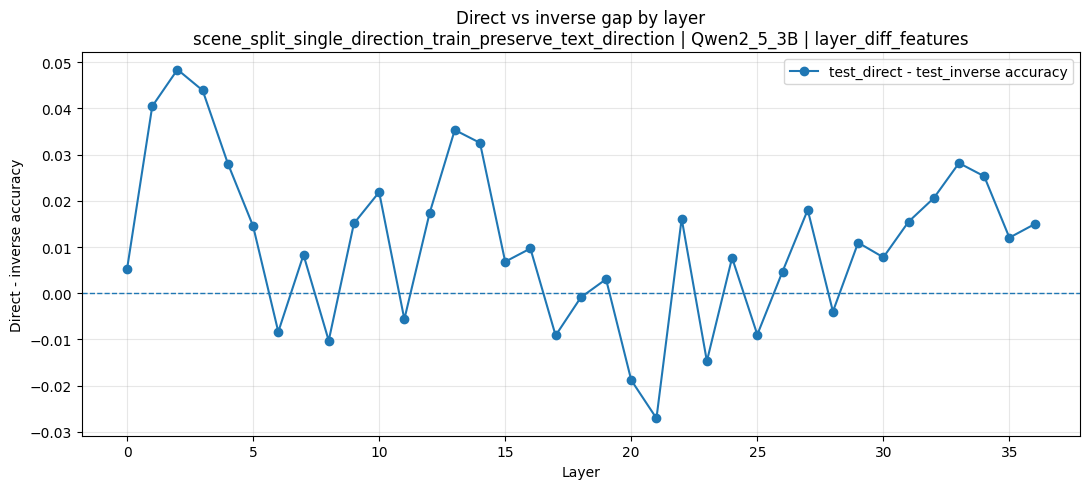

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_direct_inverse_gap_accuracy.png


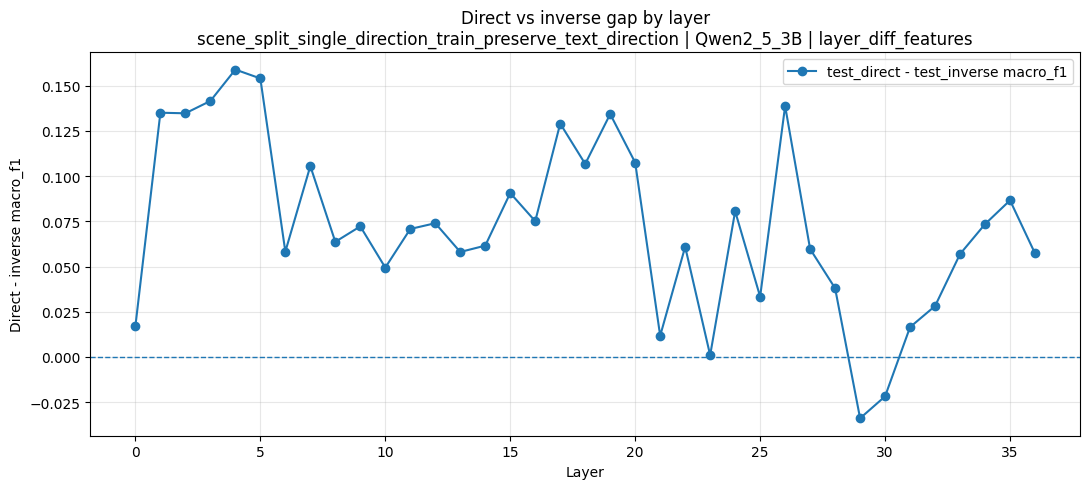

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_direct_inverse_gap_macro_f1.png


In [6]:
# ============================================================
# Plot direct-minus-inverse gap by layer
# ============================================================

def plot_direct_inverse_gap(df, metric_name, output_dir):
    gap = df[f"test_direct_{metric_name}"] - df[f"test_inverse_{metric_name}"]

    plt.figure(figsize=(11, 5))

    plt.plot(
        df["layer"],
        gap,
        marker="o",
        label=f"test_direct - test_inverse {metric_name}",
    )

    plt.axhline(0.0, linestyle="--", linewidth=1)

    plt.xlabel("Layer")
    plt.ylabel(f"Direct - inverse {metric_name}")
    plt.title(
        f"Direct vs inverse gap by layer\n"
        f"{experiment_name} | {model_tag} | {feature_key}"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_direct_inverse_gap_{metric_name}.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()

    print("Saved:", fig_path)


plot_direct_inverse_gap(layerwise_df, "accuracy", output_dir)
plot_direct_inverse_gap(layerwise_df, "macro_f1", output_dir)

In [7]:
# ============================================================
# Build per-class metric heatmap dataframes
# ============================================================

def build_per_class_metric_dataframe(data, subset_key, labels, metric):
    """
    metric:
      "precision", "recall", or "f1-score"
    """

    rows = []

    for layer_result in data["results_by_layer"]:
        layer = int(layer_result["layer"])
        report = layer_result[subset_key]["classification_report"]

        row = {"layer": layer}

        for label in labels:
            row[label] = float(report.get(label, {}).get(metric, 0.0))

        rows.append(row)

    df = pd.DataFrame(rows).set_index("layer")
    return df


per_class_dfs = {}

for subset_key in subset_keys:
    per_class_dfs[(subset_key, "precision")] = build_per_class_metric_dataframe(
        data, subset_key, label_order, "precision"
    )
    per_class_dfs[(subset_key, "recall")] = build_per_class_metric_dataframe(
        data, subset_key, label_order, "recall"
    )
    per_class_dfs[(subset_key, "f1")] = build_per_class_metric_dataframe(
        data, subset_key, label_order, "f1-score"
    )

print("Example: test_overall recall dataframe")
display(per_class_dfs[("test_overall", "recall")].head())

Example: test_overall recall dataframe


,above,below,contains,in,left_of,near,on,right_of,supports
layer,,,,,,,,,
0,0.000000,0.053030,0.000,0.000,0.440729,0.00,0.916129,0.458967,0.916129
1,0.492424,0.583333,0.125,0.500,0.759878,0.21,0.948387,0.756839,0.974194
2,0.590909,0.719697,0.250,0.375,0.857143,0.31,0.941935,0.860182,0.987097
3,0.598485,0.704545,0.250,0.375,0.881459,0.32,0.974194,0.841945,0.987097
4,0.492424,0.636364,0.125,0.375,0.854103,0.28,0.948387,0.805471,0.974194


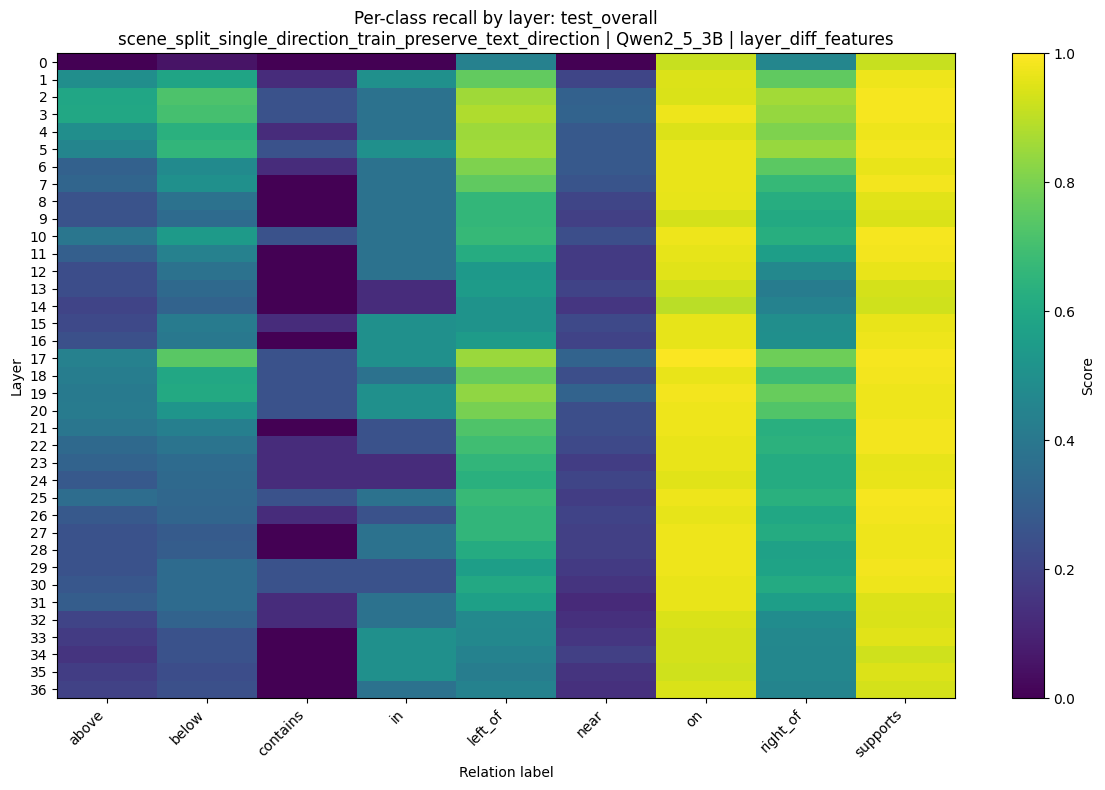

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_overall_recall_heatmap.png


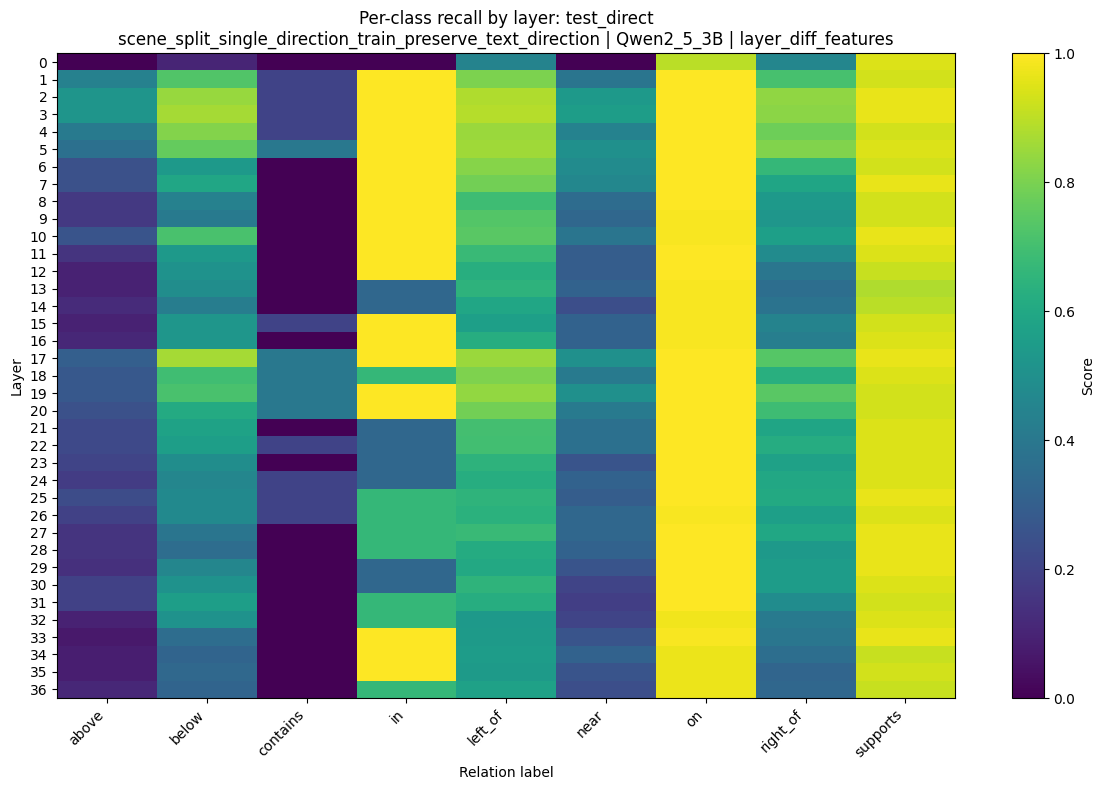

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_direct_recall_heatmap.png


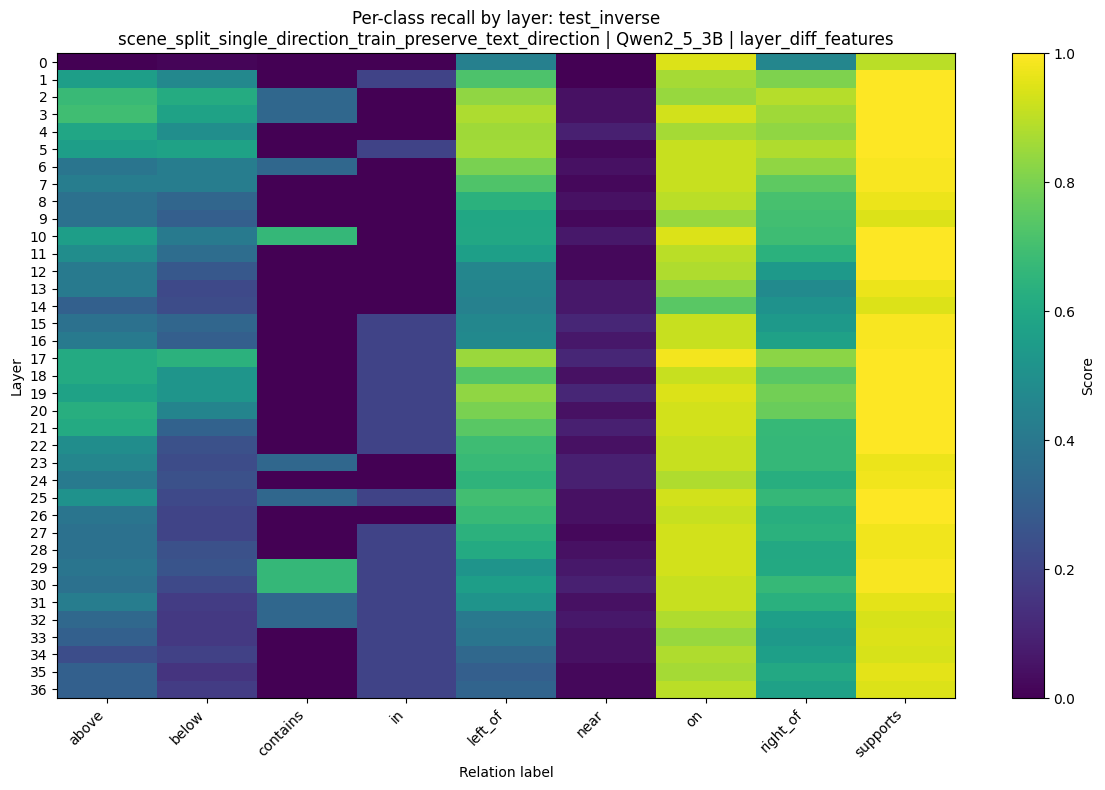

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_inverse_recall_heatmap.png


In [8]:
# ============================================================
# Plot per-class recall heatmaps
# ============================================================

def plot_heatmap(df, title, output_path, vmin=0.0, vmax=1.0):
    plt.figure(figsize=(12, 8))

    im = plt.imshow(
        df.values,
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
    )

    plt.colorbar(im, label="Score")

    plt.xticks(
        ticks=np.arange(len(df.columns)),
        labels=df.columns,
        rotation=45,
        ha="right",
    )

    plt.yticks(
        ticks=np.arange(len(df.index)),
        labels=df.index,
    )

    plt.xlabel("Relation label")
    plt.ylabel("Layer")
    plt.title(title)
    plt.tight_layout()

    plt.savefig(output_path, dpi=200)
    plt.show()

    print("Saved:", output_path)


for subset_key in subset_keys:
    df = per_class_dfs[(subset_key, "recall")]

    fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_{subset_key}_recall_heatmap.png"

    plot_heatmap(
        df=df,
        title=(
            f"Per-class recall by layer: {subset_key}\n"
            f"{experiment_name} | {model_tag} | {feature_key}"
        ),
        output_path=fig_path,
    )

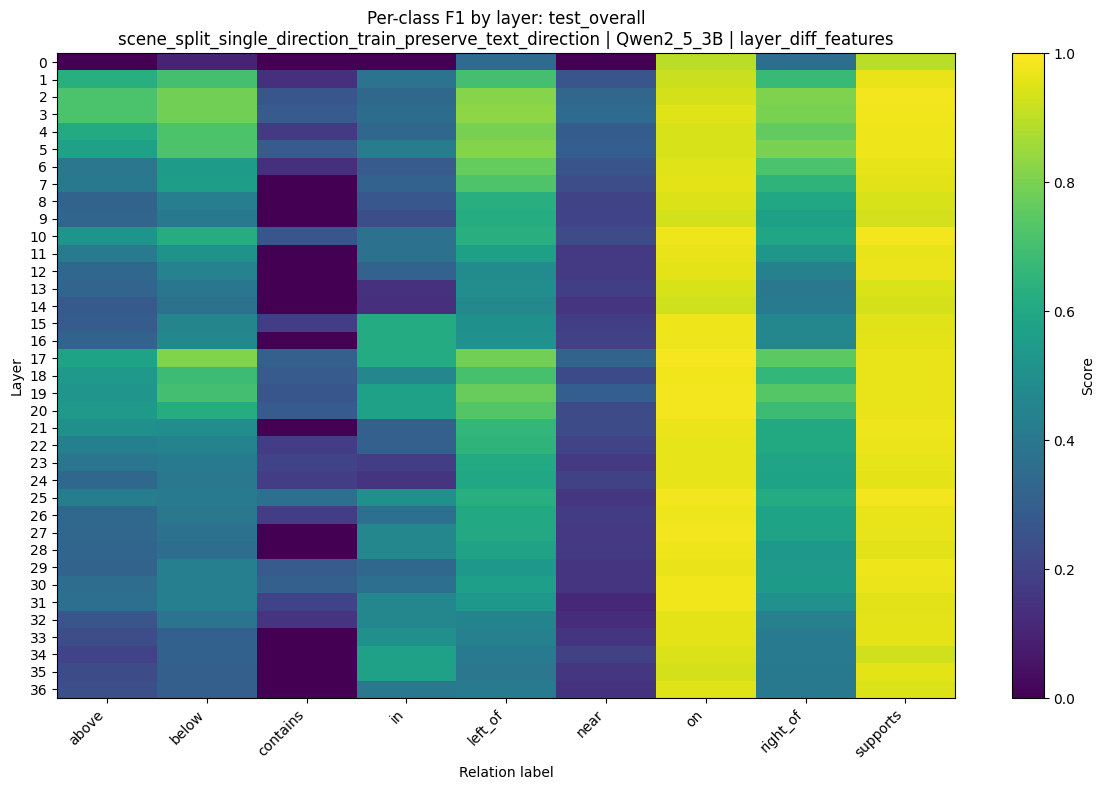

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_overall_f1_heatmap.png


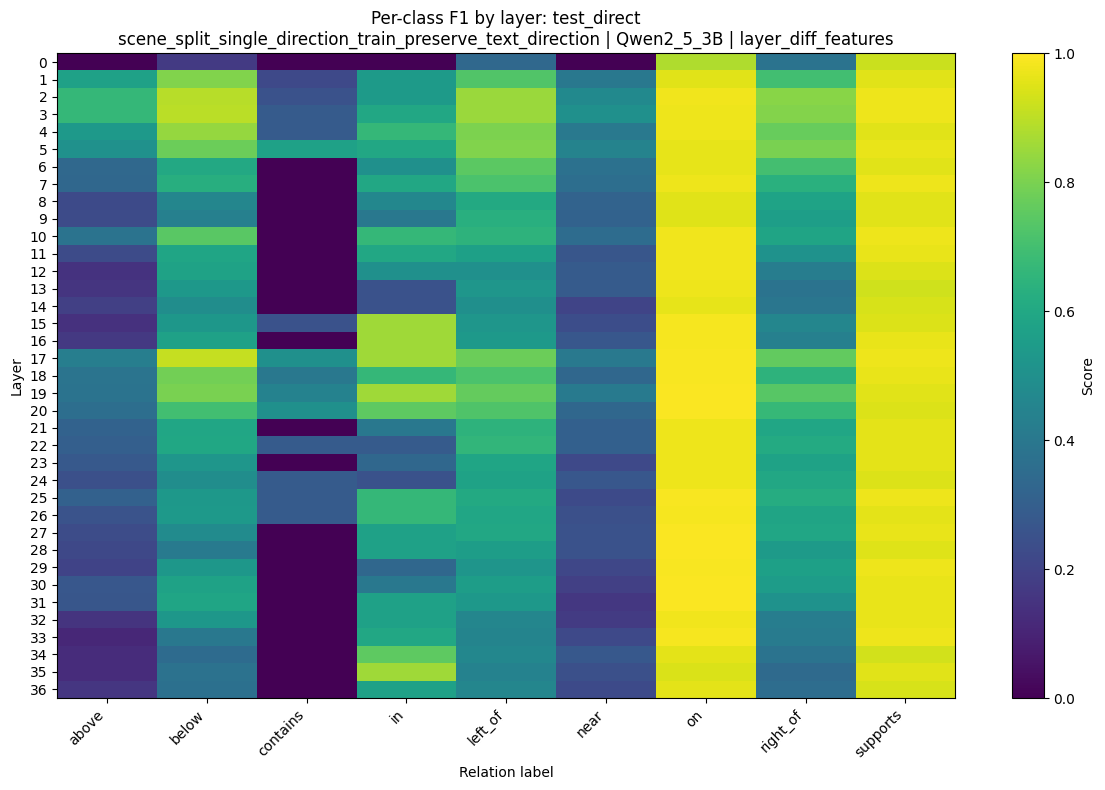

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_direct_f1_heatmap.png


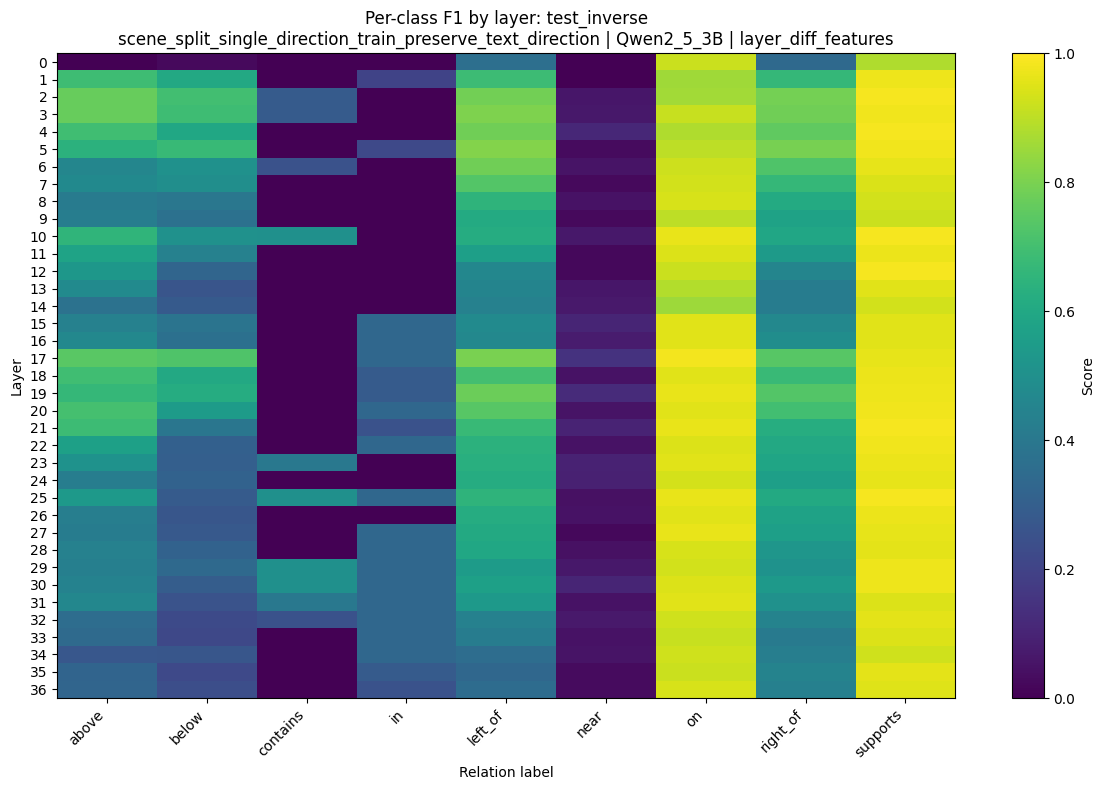

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_inverse_f1_heatmap.png


In [9]:
# ============================================================
# Plot per-class F1 heatmaps
# ============================================================

for subset_key in subset_keys:
    df = per_class_dfs[(subset_key, "f1")]

    fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_{subset_key}_f1_heatmap.png"

    plot_heatmap(
        df=df,
        title=(
            f"Per-class F1 by layer: {subset_key}\n"
            f"{experiment_name} | {model_tag} | {feature_key}"
        ),
        output_path=fig_path,
    )

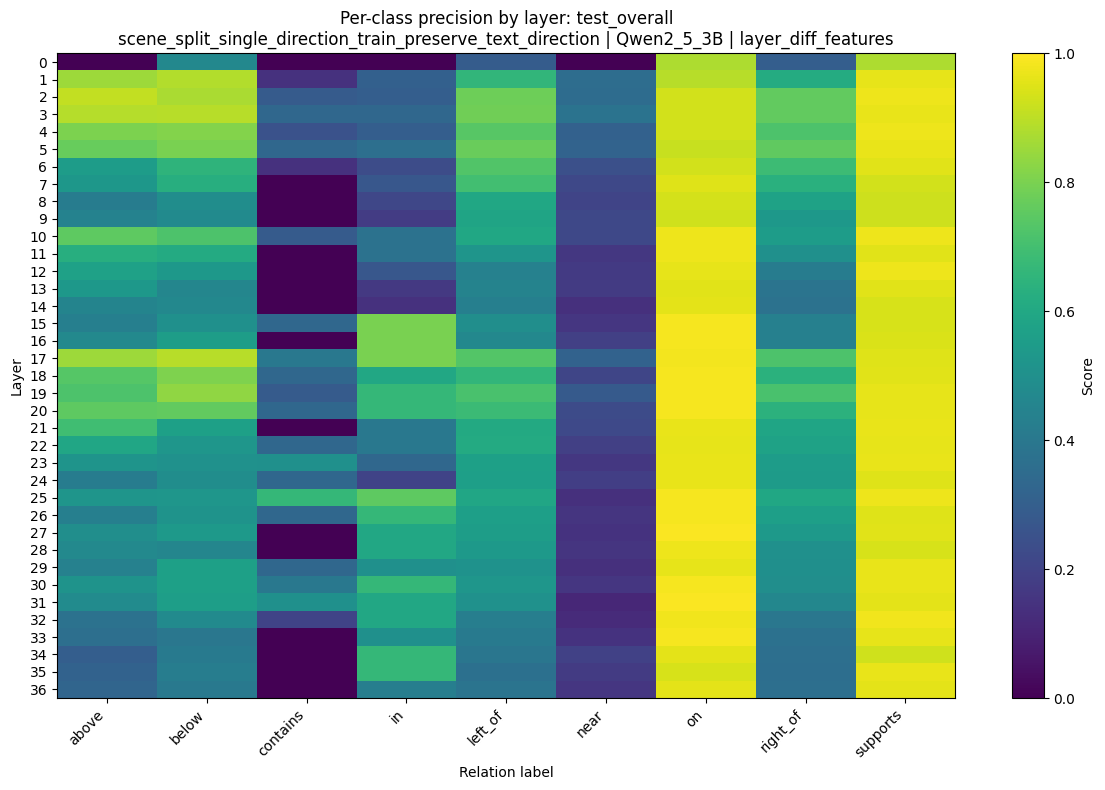

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_overall_precision_heatmap.png


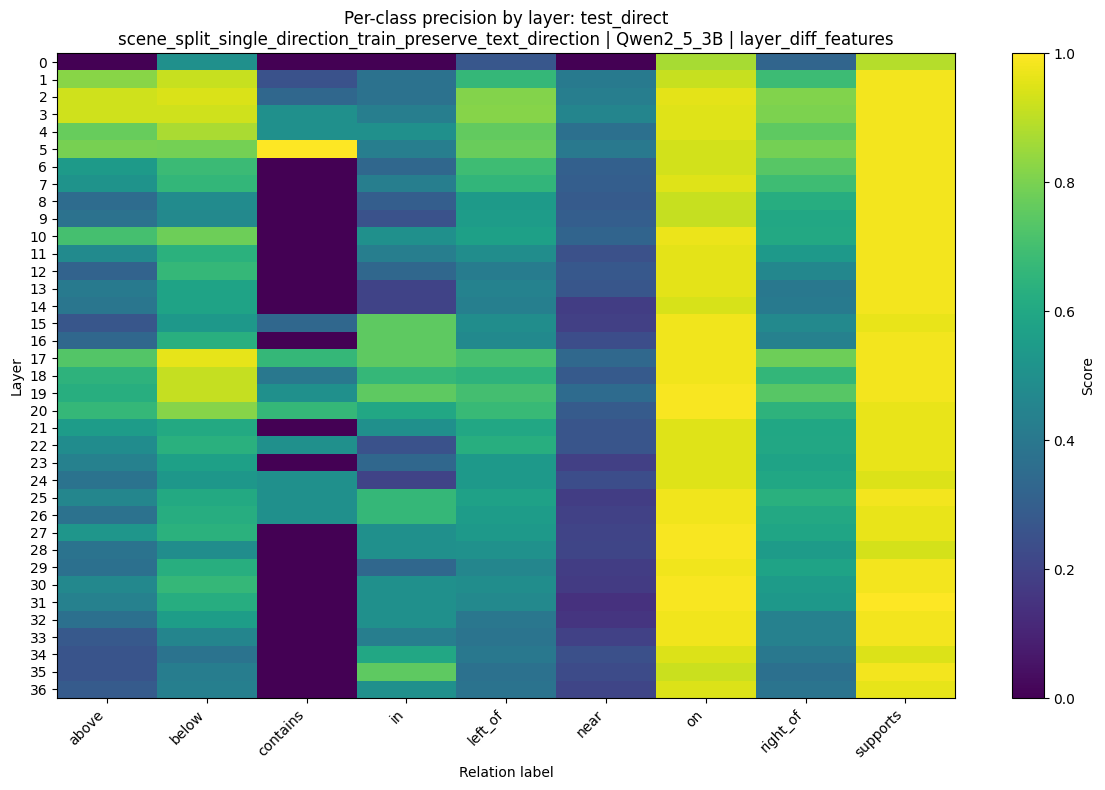

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_direct_precision_heatmap.png


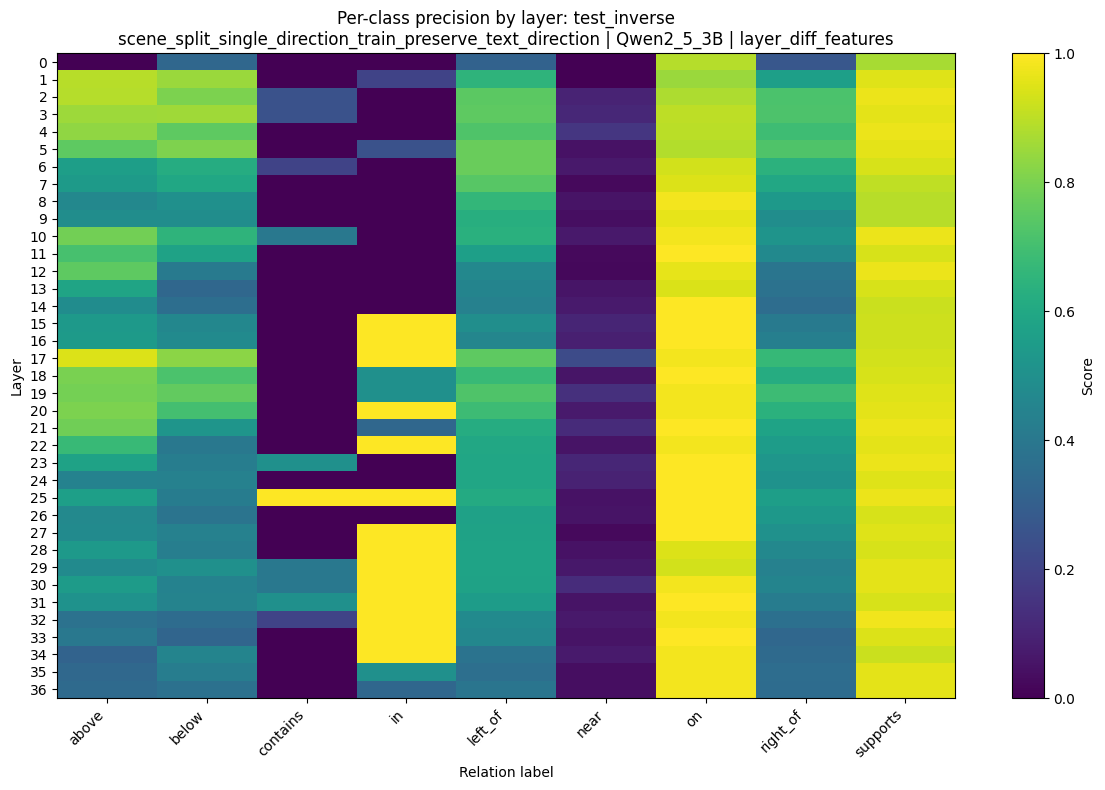

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_inverse_precision_heatmap.png


In [10]:
# ============================================================
# Plot per-class precision heatmaps
# ============================================================

for subset_key in subset_keys:
    df = per_class_dfs[(subset_key, "precision")]

    fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_{subset_key}_precision_heatmap.png"

    plot_heatmap(
        df=df,
        title=(
            f"Per-class precision by layer: {subset_key}\n"
            f"{experiment_name} | {model_tag} | {feature_key}"
        ),
        output_path=fig_path,
    )

In [11]:
# ============================================================
# Find best layers for each subset
# ============================================================

def find_best_layer(data, subset_key, metric="macro_f1"):
    best_layer_result = max(
        data["results_by_layer"],
        key=lambda r: r[subset_key][metric],
    )

    return {
        "subset": subset_key,
        "metric": metric,
        "layer": int(best_layer_result["layer"]),
        "score": float(best_layer_result[subset_key][metric]),
        "accuracy": float(best_layer_result[subset_key]["accuracy"]),
        "macro_f1": float(best_layer_result[subset_key]["macro_f1"]),
    }


best_layer_rows = []

for subset_key in subset_keys:
    best_layer_rows.append(find_best_layer(data, subset_key, metric="macro_f1"))
    best_layer_rows.append(find_best_layer(data, subset_key, metric="accuracy"))

best_layer_df = pd.DataFrame(best_layer_rows)

best_layer_csv = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_best_layers.csv"
best_layer_df.to_csv(best_layer_csv, index=False)

print("Best layers:")
display(best_layer_df)

print("Saved:", best_layer_csv)

Best layers:


,subset,metric,layer,score,accuracy,macro_f1
0,test_overall,macro_f1,17,0.680128,0.770030,0.680128
1,test_overall,accuracy,3,0.801187,0.801187,0.671857
2,test_direct,macro_f1,17,0.732722,0.765487,0.732722
3,test_direct,accuracy,3,0.823009,0.823009,0.729171
4,test_inverse,macro_f1,17,0.603716,0.774627,0.603716
5,test_inverse,accuracy,3,0.779104,0.779104,0.587657


Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_best_layers.csv


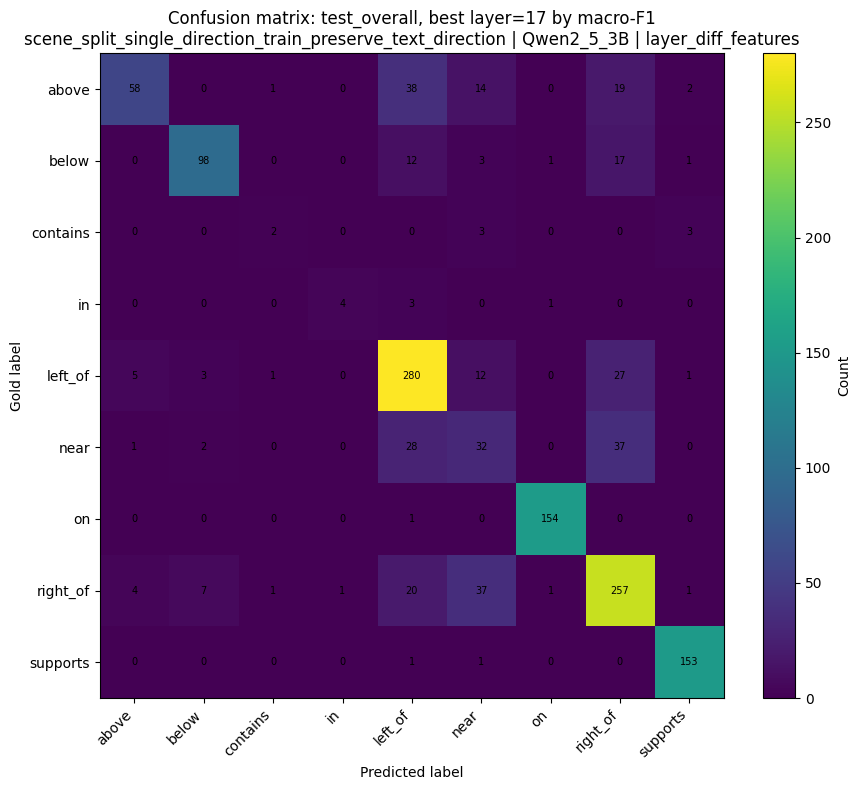

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_overall_best_layer17_confusion_count.png


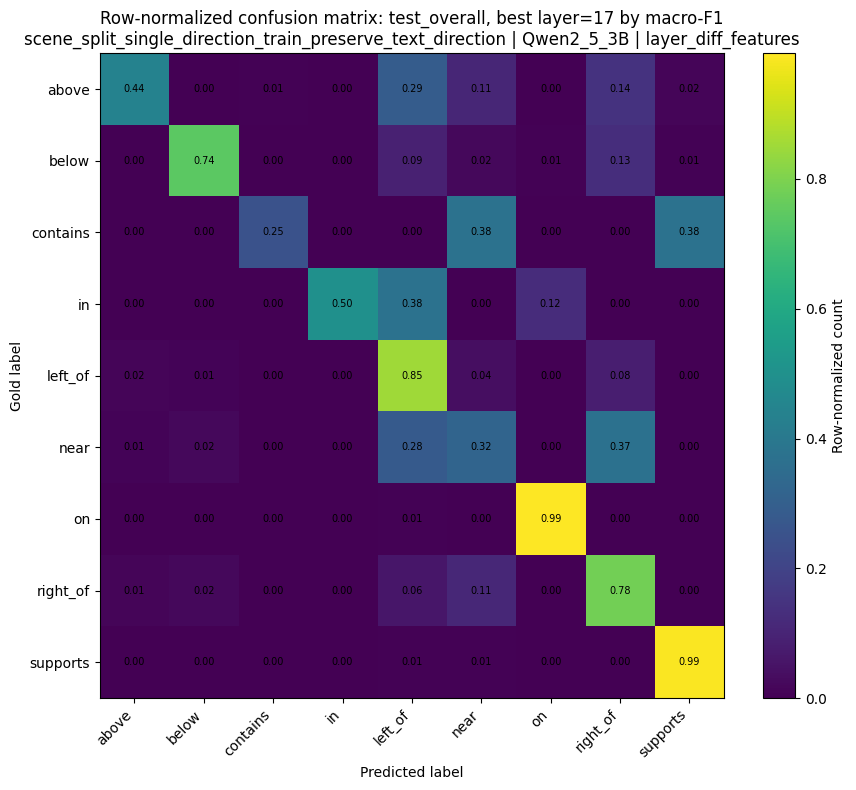

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_overall_best_layer17_confusion_normalized.png


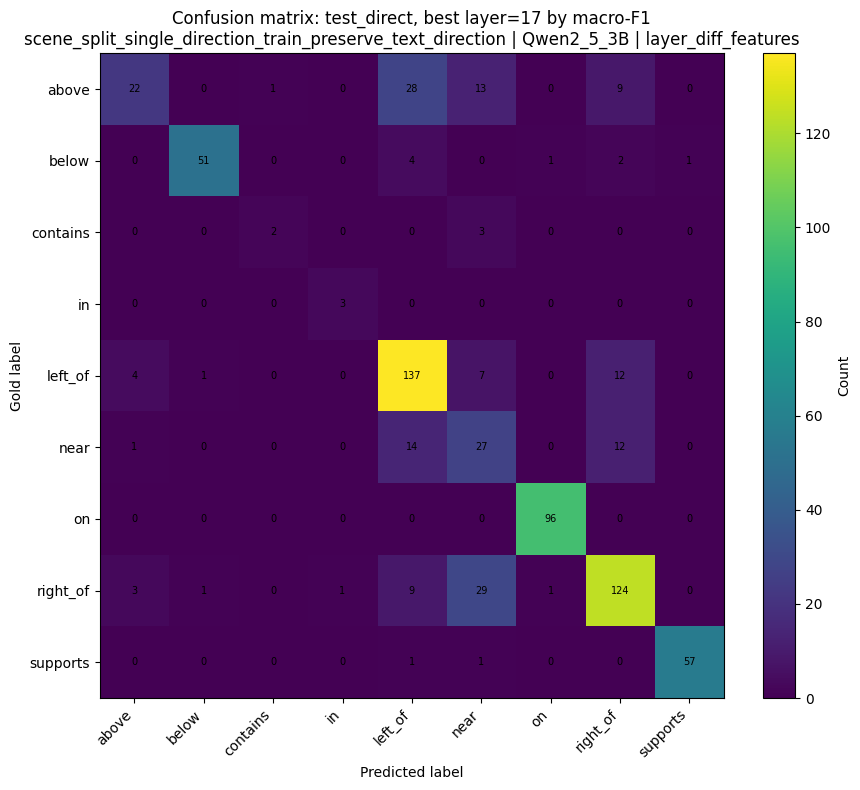

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_direct_best_layer17_confusion_count.png


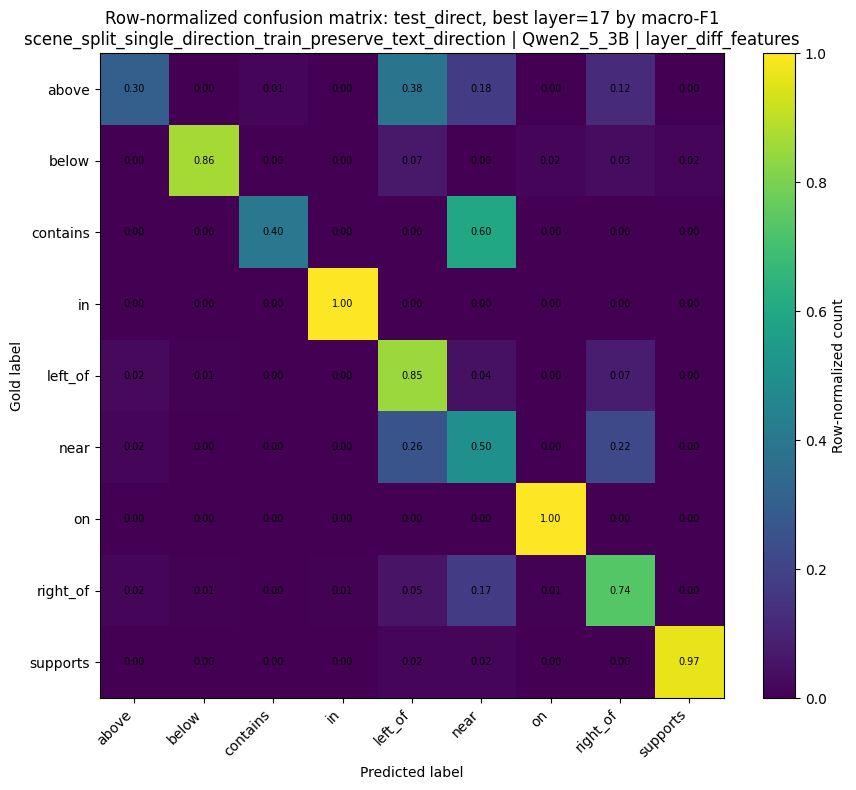

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_direct_best_layer17_confusion_normalized.png


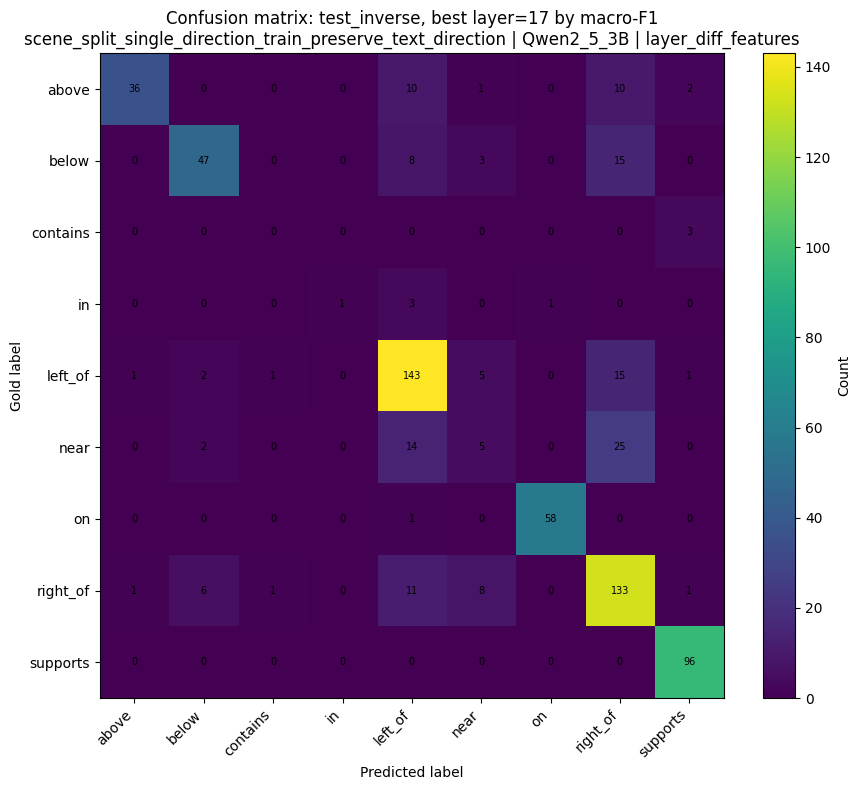

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_inverse_best_layer17_confusion_count.png


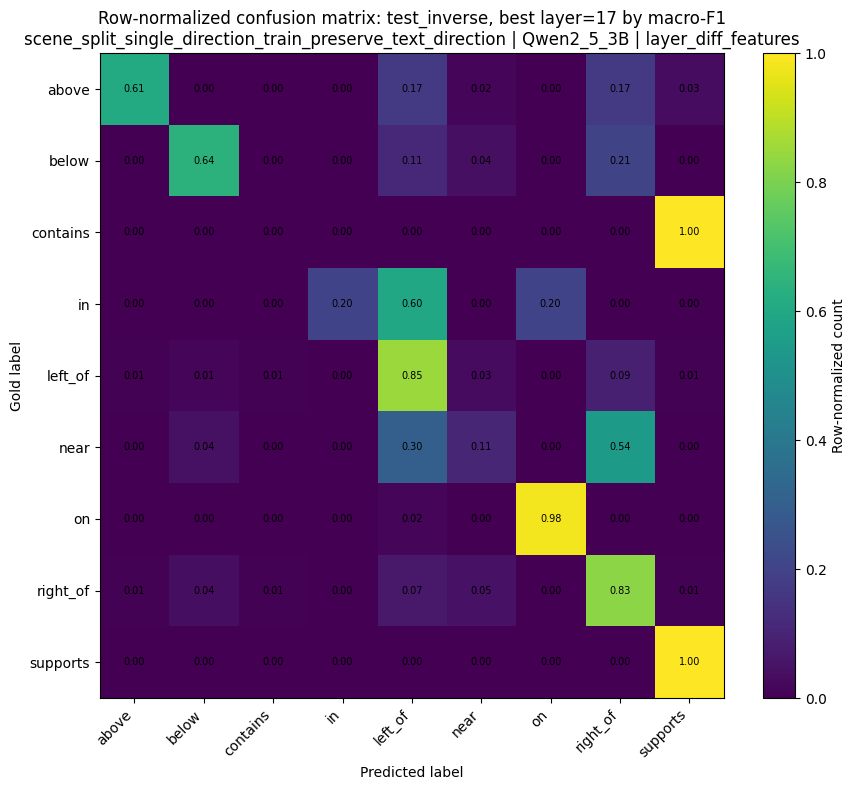

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_inverse_best_layer17_confusion_normalized.png


In [12]:
# ============================================================
# Plot best-layer confusion matrices
# ============================================================

def get_layer_result(data, layer_id):
    for layer_result in data["results_by_layer"]:
        if int(layer_result["layer"]) == int(layer_id):
            return layer_result

    raise ValueError(f"Layer not found: {layer_id}")


def plot_confusion_matrix(cm, labels, title, output_path, normalize=False):
    cm = np.array(cm, dtype=float)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_plot = np.divide(
            cm,
            row_sums,
            out=np.zeros_like(cm),
            where=row_sums != 0,
        )
        color_label = "Row-normalized count"
    else:
        cm_plot = cm
        color_label = "Count"

    plt.figure(figsize=(9, 8))

    im = plt.imshow(
        cm_plot,
        aspect="auto",
        interpolation="nearest",
    )

    plt.colorbar(im, label=color_label)

    plt.xticks(
        ticks=np.arange(len(labels)),
        labels=labels,
        rotation=45,
        ha="right",
    )

    plt.yticks(
        ticks=np.arange(len(labels)),
        labels=labels,
    )

    plt.xlabel("Predicted label")
    plt.ylabel("Gold label")
    plt.title(title)

    # Add values to cells
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            if normalize:
                text = f"{cm_plot[i, j]:.2f}"
            else:
                text = str(int(cm[i, j]))

            plt.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=7,
            )

    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.show()

    print("Saved:", output_path)


for subset_key in subset_keys:
    best_info = find_best_layer(data, subset_key, metric="macro_f1")
    best_layer = best_info["layer"]

    layer_result = get_layer_result(data, best_layer)

    cm = layer_result[subset_key]["confusion_matrix"]
    labels = layer_result[subset_key]["label_order"]

    fig_path_count = output_dir / (
        f"step7_{experiment_name}_{model_tag}_{feature_key}_"
        f"{subset_key}_best_layer{best_layer}_confusion_count.png"
    )

    plot_confusion_matrix(
        cm=cm,
        labels=labels,
        title=(
            f"Confusion matrix: {subset_key}, best layer={best_layer} by macro-F1\n"
            f"{experiment_name} | {model_tag} | {feature_key}"
        ),
        output_path=fig_path_count,
        normalize=False,
    )

    fig_path_norm = output_dir / (
        f"step7_{experiment_name}_{model_tag}_{feature_key}_"
        f"{subset_key}_best_layer{best_layer}_confusion_normalized.png"
    )

    plot_confusion_matrix(
        cm=cm,
        labels=labels,
        title=(
            f"Row-normalized confusion matrix: {subset_key}, best layer={best_layer} by macro-F1\n"
            f"{experiment_name} | {model_tag} | {feature_key}"
        ),
        output_path=fig_path_norm,
        normalize=True,
    )

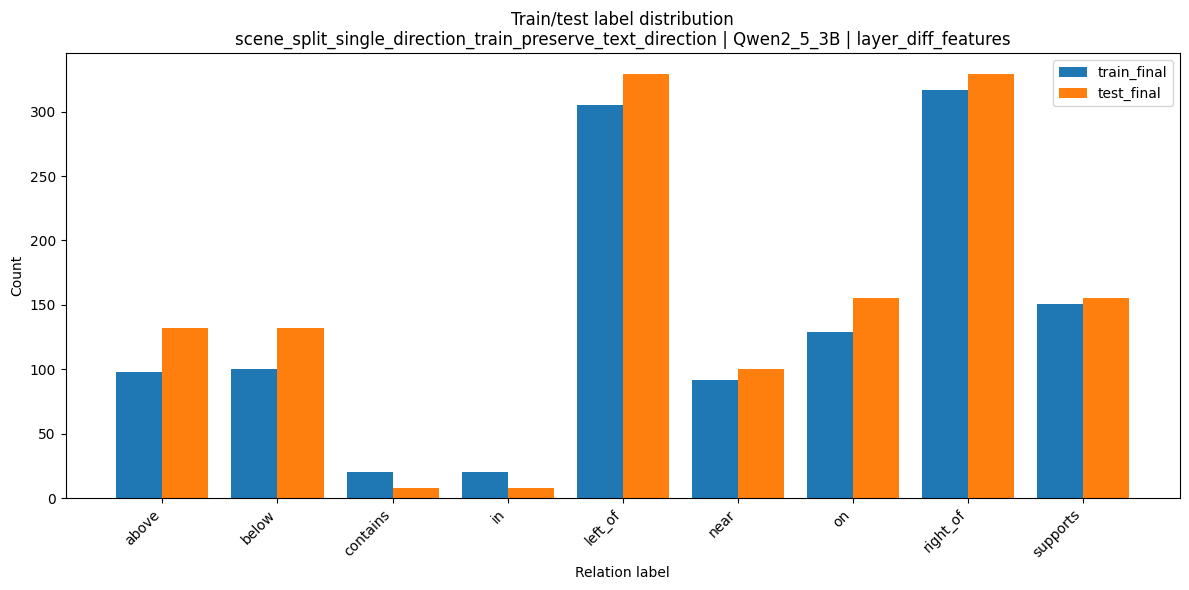

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_train_test_label_distribution.png


In [13]:
# ============================================================
# Plot train/test label distribution
# ============================================================

def plot_label_distribution(count_dicts, labels, title, output_path):
    """
    count_dicts:
      list of (name, dict)
    """

    x = np.arange(len(labels))
    width = 0.8 / len(count_dicts)

    plt.figure(figsize=(12, 6))

    for i, (name, counts) in enumerate(count_dicts):
        values = [counts.get(label, 0) for label in labels]
        offset = (i - (len(count_dicts) - 1) / 2) * width

        plt.bar(
            x + offset,
            values,
            width=width,
            label=name,
        )

    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel("Count")
    plt.xlabel("Relation label")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(output_path, dpi=200)
    plt.show()

    print("Saved:", output_path)


train_counts = scene_split_info.get("train_label_counts_final", {})
test_counts = scene_split_info.get("test_label_counts_final", {})

fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_train_test_label_distribution.png"

plot_label_distribution(
    count_dicts=[
        ("train_final", train_counts),
        ("test_final", test_counts),
    ],
    labels=label_order,
    title=(
        f"Train/test label distribution\n"
        f"{experiment_name} | {model_tag} | {feature_key}"
    ),
    output_path=fig_path,
)

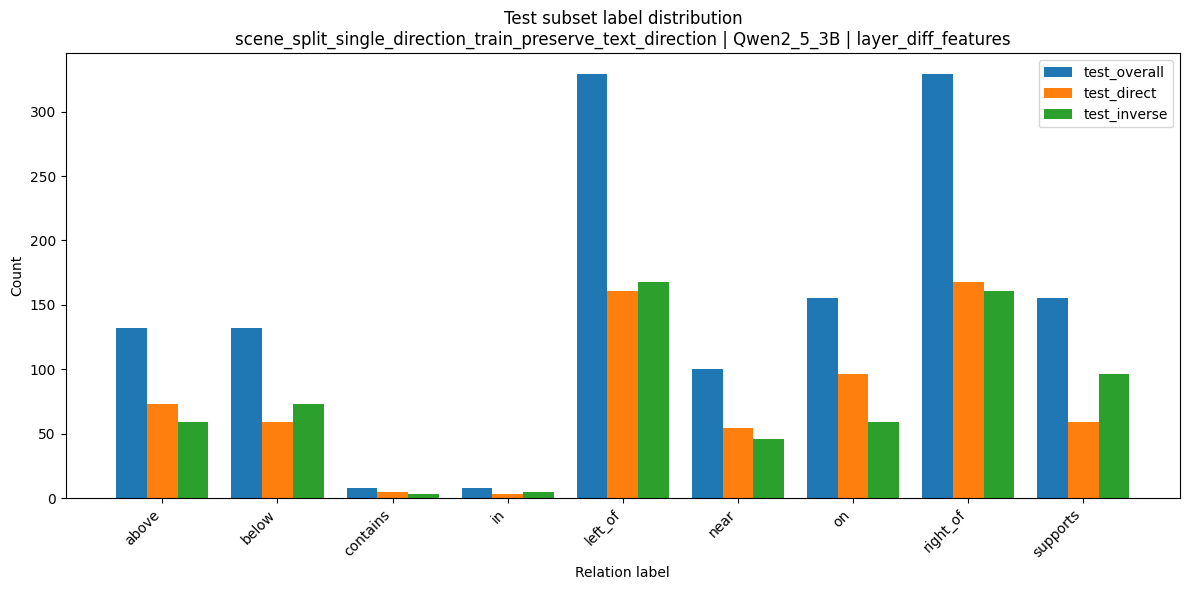

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_subset_label_distribution.png


In [14]:
# ============================================================
# Plot test subset label distributions
# ============================================================

test_overall_counts = test_subset_summary.get("test_overall", {}).get("label_counts", {})
test_direct_counts = test_subset_summary.get("test_direct", {}).get("label_counts", {})
test_inverse_counts = test_subset_summary.get("test_inverse", {}).get("label_counts", {})

fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_test_subset_label_distribution.png"

plot_label_distribution(
    count_dicts=[
        ("test_overall", test_overall_counts),
        ("test_direct", test_direct_counts),
        ("test_inverse", test_inverse_counts),
    ],
    labels=label_order,
    title=(
        f"Test subset label distribution\n"
        f"{experiment_name} | {model_tag} | {feature_key}"
    ),
    output_path=fig_path,
)

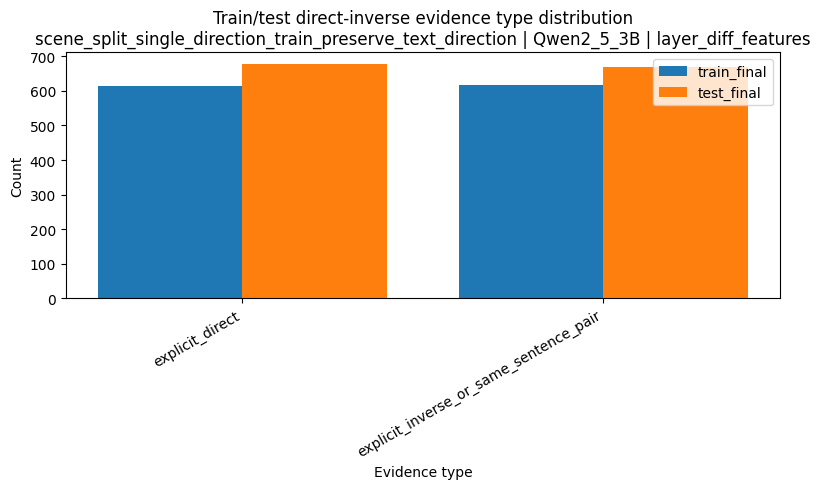

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_train_test_evidence_type_distribution.png


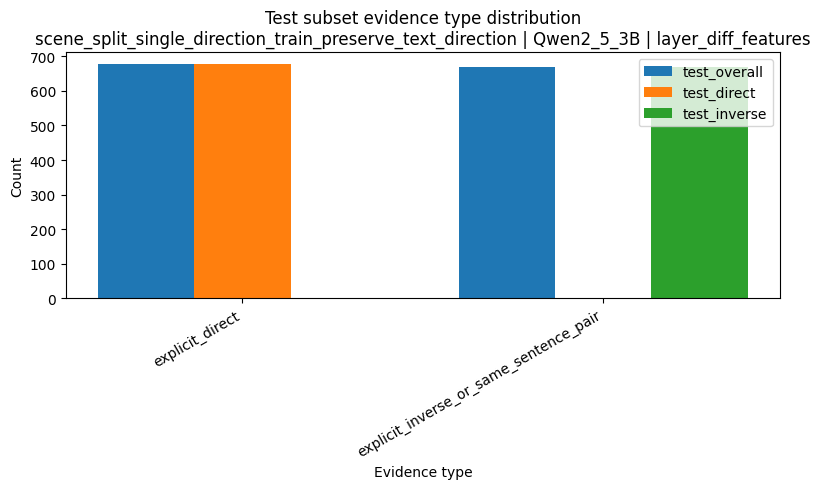

Saved: /content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_test_subset_evidence_type_distribution.png


In [15]:
# ============================================================
# Plot direct/inverse evidence type distribution
# ============================================================

def plot_evidence_type_distribution(count_dicts, title, output_path):
    evidence_labels = sorted(
        set().union(*[set(counts.keys()) for _, counts in count_dicts])
    )

    x = np.arange(len(evidence_labels))
    width = 0.8 / len(count_dicts)

    plt.figure(figsize=(8, 5))

    for i, (name, counts) in enumerate(count_dicts):
        values = [counts.get(label, 0) for label in evidence_labels]
        offset = (i - (len(count_dicts) - 1) / 2) * width

        plt.bar(
            x + offset,
            values,
            width=width,
            label=name,
        )

    plt.xticks(x, evidence_labels, rotation=30, ha="right")
    plt.ylabel("Count")
    plt.xlabel("Evidence type")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(output_path, dpi=200)
    plt.show()

    print("Saved:", output_path)


train_evidence_counts = scene_split_info.get("train_evidence_type_counts_final", {})
test_evidence_counts = scene_split_info.get("test_evidence_type_counts_final", {})

fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_train_test_evidence_type_distribution.png"

plot_evidence_type_distribution(
    count_dicts=[
        ("train_final", train_evidence_counts),
        ("test_final", test_evidence_counts),
    ],
    title=(
        f"Train/test direct-inverse evidence type distribution\n"
        f"{experiment_name} | {model_tag} | {feature_key}"
    ),
    output_path=fig_path,
)


test_overall_evidence = test_subset_summary.get("test_overall", {}).get("evidence_type_counts", {})
test_direct_evidence = test_subset_summary.get("test_direct", {}).get("evidence_type_counts", {})
test_inverse_evidence = test_subset_summary.get("test_inverse", {}).get("evidence_type_counts", {})

fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_test_subset_evidence_type_distribution.png"

plot_evidence_type_distribution(
    count_dicts=[
        ("test_overall", test_overall_evidence),
        ("test_direct", test_direct_evidence),
        ("test_inverse", test_inverse_evidence),
    ],
    title=(
        f"Test subset evidence type distribution\n"
        f"{experiment_name} | {model_tag} | {feature_key}"
    ),
    output_path=fig_path,
)

In [16]:
# ============================================================
# Save Step 7 summary JSON
# ============================================================

step7_summary = {
    "source_step6_json": str(json_path),
    "output_dir": str(output_dir),
    "experiment_name": experiment_name,
    "model_tag": model_tag,
    "feature_key": feature_key,
    "num_layers": num_layers,
    "label_order": label_order,
    "best_layers": best_layer_df.to_dict(orient="records"),
    "scene_split_info": scene_split_info,
    "test_subset_summary": test_subset_summary,
}

summary_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(step7_summary, f, indent=2, ensure_ascii=False)

print("Saved Step 7 summary:")
print(summary_path)

Saved Step 7 summary:
/content/step7_pilot4_single_direction_train_figures/step7_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_summary.json


In [17]:
# ============================================================
# Zip Step 7 outputs
# ============================================================

import shutil

zip_base = f"/content/step7_pilot4_{experiment_name}_{model_tag}_{feature_key}_figures"
zip_path = shutil.make_archive(
    base_name=zip_base,
    format="zip",
    root_dir=output_dir,
)

print("Created Step 7 output zip:")
print(zip_path)

Created Step 7 output zip:
/content/step7_pilot4_scene_split_single_direction_train_preserve_text_direction_Qwen2_5_3B_layer_diff_features_figures.zip


In [19]:
# ============================================================
# Download Step 7 output zip
# ============================================================

from google.colab import files

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>